# FDC-Monitoring LangGraph RAG Agent

**기존 `agentic_rag.ipynb`를 보존하면서**, LangGraph의 조건부 분기를 활용해
VOC 응답 흐름을 **노드 기반 그래프**로 구조화한 확장 버전입니다.

---

## 그래프 구조

```
START
  └─► extract_entities
         └─► validate_entities
                ├─[invalid_entity]──► refusal_answer ──► END
                ├─[need_clarification]► clarification_answer ──► END
                └─[valid_query]──► retrieve_context
                                       └─► generate_answer
                                              └─► validate_citation ──► END
```

## 각 노드 역할

| 노드 | 역할 |
|---|---|
| `extract_entities` | 질문에서 alarm_code / equipment_id / intent 추출 |
| `validate_entities` | master CSV 대조 → invalid / clarification / valid 결정 |
| `retrieve_context` | FAISS retriever로 관련 section chunk 검색 |
| `generate_answer` | 검색 근거 기반 6섹션 답변 생성 |
| `validate_citation` | 답변 속 [SECTION-ID]가 검색 컨텍스트에 존재하는지 검증 |
| `refusal_answer` | 존재하지 않는 코드·설비 또는 범위 밖 요청 거절 |
| `clarification_answer` | 부족한 정보를 되묻는 명확화 요청 |

## 기존 MVP와의 차이

| | `agentic_rag.ipynb` (MVP) | `langgraph_rag_agent.ipynb` (이번) |
|---|---|---|
| 흐름 제어 | ReAct loop (LLM이 자유 판단) | 명시적 노드 그래프 |
| 엔티티 검증 | LLM 프롬프트에 의존 | master CSV 대조 |
| 분기 처리 | LLM이 암묵적 처리 | 조건부 엣지로 명시 |
| 인용 검증 | 없음 | validate_citation 노드 |
| 추적·디버깅 | LangSmith trace | 노드별 상태 덤프 가능 |

## 0. (필요 시) 의존성 설치

In [1]:
%pip install -q langchain langchain-openai langchain-community langchain-text-splitters
%pip install -q faiss-cpu python-dotenv langgraph

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. 환경 변수 로드 + API 검증

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

env_path = PROJECT_ROOT / ".env"
loaded = load_dotenv(dotenv_path=env_path, override=True)
print(f".env 로드: {loaded}  (경로: {env_path})")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")

def _mask(k):
    if not k:
        return "(없음)"
    return k[:6] + "..." + k[-4:] if len(k) > 12 else "***"

print(f"OPENAI_API_KEY    : {_mask(OPENAI_API_KEY)}")
print(f"LANGSMITH_API_KEY : {_mask(LANGSMITH_API_KEY)}")

assert OPENAI_API_KEY, "OPENAI_API_KEY 가 .env 에 없습니다."

if LANGSMITH_API_KEY:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_API_KEY"] = LANGSMITH_API_KEY
    os.environ.setdefault("LANGCHAIN_PROJECT", "fdc-langgraph-rag")
    print("LangSmith tracing 활성화 — project=fdc-langgraph-rag")
else:
    print("LangSmith 키 없음 — 트레이싱 비활성화")

.env 로드: True  (경로: c:\Users\User\Documents\Gen AI\Project\.env)
OPENAI_API_KEY    : sk-pro...WW8A
LANGSMITH_API_KEY : lsv2_p...f6fb
LangSmith tracing 활성화 — project=fdc-langgraph-rag


## 2. 매뉴얼 로드 + section chunk 생성

`agentic_rag.ipynb`와 동일한 로직을 재사용합니다.

In [3]:
MANUAL_DIR = PROJECT_ROOT / "data" / "manuals"
MANUAL_FILES = [
    "alarm_code_guide.md",
    "troubleshooting_guide.md",
    "operation_policy.md",
    "system_user_manual.md",
    "faq.md",
]

raw_manuals = {}
for fname in MANUAL_FILES:
    path = MANUAL_DIR / fname
    text = path.read_text(encoding="utf-8")
    raw_manuals[fname] = text
    print(f"  [{fname}] {len(text):,} chars")

  [alarm_code_guide.md] 12,230 chars
  [troubleshooting_guide.md] 12,245 chars
  [operation_policy.md] 5,980 chars
  [system_user_manual.md] 6,103 chars
  [faq.md] 4,603 chars


In [4]:
import re
from langchain_core.documents import Document

HEADER_RE = re.compile(
    r"^(?P<hashes>#{2,3})\s+(?P<sid>[A-Z]+-[A-Z0-9-]+)\s*\|\s*(?P<title>.+?)\s*$",
    re.MULTILINE,
)


def split_by_section(file_name: str, text: str):
    matches = list(HEADER_RE.finditer(text))
    if not matches:
        return []
    docs = []
    for i, m in enumerate(matches):
        start = m.start()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        body = text[start:end].rstrip()
        sid = m.group("sid")
        title = m.group("title").strip()
        citation = f"[{sid}] {title}"
        if len(citation) > 60:
            citation = citation[:57] + "..."
        docs.append(
            Document(
                page_content=body,
                metadata={
                    "file_name": file_name,
                    "section_id": sid,
                    "title": title,
                    "citation": citation,
                },
            )
        )
    return docs


chunks = []
for fname, text in raw_manuals.items():
    chunks.extend(split_by_section(fname, text))

print(f"총 chunk 수: {len(chunks)}")
from collections import Counter
for fname, n in Counter(c.metadata["file_name"] for c in chunks).items():
    print(f"  {fname}: {n}")

총 chunk 수: 91
  alarm_code_guide.md: 42
  troubleshooting_guide.md: 19
  operation_policy.md: 10
  system_user_manual.md: 10
  faq.md: 10


## 3. FAISS Vectorstore + Retriever

In [5]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS

embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectordb = FAISS.from_documents(chunks, embedding)
retriever = vectordb.as_retriever(search_kwargs={"k": 4})

print(f"FAISS index 생성 완료 — 벡터 {vectordb.index.ntotal}개")

# Sanity check
_test = retriever.invoke("TEMP-H-001 챔버 과열 임계치")
print("Sanity check (TEMP-H-001 검색):")
for i, d in enumerate(_test[:2], 1):
    print(f"  [{i}] {d.metadata['citation']}")

FAISS index 생성 완료 — 벡터 91개
Sanity check (TEMP-H-001 검색):
  [1] [AC-TEMP-H-001] 챔버 과열 High (TEMP-H-001)
  [2] [AC-TEMP-C-001] 챔버 과열 Critical (TEMP-C-001)


## 4. Master 데이터 로드

`validate_entities` 노드에서 알람 코드와 설비 ID의 존재 여부를 검증하는 데 사용합니다.

In [6]:
import csv

ALARM_MASTER_PATH = PROJECT_ROOT / "data" / "db" / "alarm_code_master.csv"
EQUIP_MASTER_PATH = PROJECT_ROOT / "data" / "db" / "equipment_master.csv"

alarm_codes_valid: set[str] = set()
with open(ALARM_MASTER_PATH, encoding="utf-8") as f:
    for row in csv.DictReader(f):
        alarm_codes_valid.add(row["alarm_code"].strip())

equipment_ids_valid: set[str] = set()
with open(EQUIP_MASTER_PATH, encoding="utf-8") as f:
    for row in csv.DictReader(f):
        equipment_ids_valid.add(row["equipment_id"].strip())

print(f"등록 알람 코드: {len(alarm_codes_valid)}개  (예: {sorted(alarm_codes_valid)[:4]})")
print(f"등록 설비 ID:   {len(equipment_ids_valid)}개  (예: {sorted(equipment_ids_valid)[:4]})")

등록 알람 코드: 42개  (예: ['CHEM-H-001', 'CHEM-W-001', 'COMM-H-001', 'COMM-M-001'])
등록 설비 ID:   30개  (예: ['CLN-WET-01', 'CLN-WET-02', 'CMP-POL-01', 'CMP-POL-02'])


## 5. LangGraph State 정의

`VOCState`는 그래프의 모든 노드가 공유하는 상태 객체입니다.  
각 노드는 `dict`를 반환해 해당 키만 업데이트하며, 나머지 키는 유지됩니다.

In [7]:
from typing import Optional, Literal
from typing_extensions import TypedDict


class VOCState(TypedDict):
    """그래프 전체를 흐르는 상태 스키마."""

    # ── 입력
    question: str

    # ── extract_entities 결과
    alarm_code: Optional[str]     # 추출된 알람 코드 (없으면 None)
    equipment_id: Optional[str]   # 추출된 설비 ID (없으면 None)
    intent: Optional[str]         # alarm_inquiry / sop_inquiry / policy_inquiry /
                                  # symptom / system_usage / out_of_scope / unknown

    # ── validate_entities 결과
    validation_status: Optional[Literal["valid_query", "invalid_entity", "need_clarification"]]
    validation_reason: Optional[str]

    # ── retrieve_context 결과
    retrieved_context: Optional[str]
    retrieved_section_ids: Optional[list]

    # ── generate_answer 결과
    answer: Optional[str]

    # ── validate_citation 결과
    cited_section_ids: Optional[list]
    citation_valid: Optional[bool]

    # ── 최종 출력
    final_answer: Optional[str]


print("VOCState 정의 완료")
print(f"필드: {list(VOCState.__annotations__.keys())}")

VOCState 정의 완료
필드: ['question', 'alarm_code', 'equipment_id', 'intent', 'validation_status', 'validation_reason', 'retrieved_context', 'retrieved_section_ids', 'answer', 'cited_section_ids', 'citation_valid', 'final_answer']


## 6. 노드 구현

### 6-1. `extract_entities` — 엔티티 추출

In [8]:
import json as _json

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

_EXTRACT_TMPL = """다음 질문에서 아래 정보를 JSON으로 추출하세요.

질문: {question}

추출 항목:
- alarm_code: 알람 코드 (예: TEMP-H-001, PRES-C-001). 언급 없으면 null
- equipment_id: 설비 ID (예: ETCH-DRY-01, THIN-CVD-02). 언급 없으면 null
- intent: 다음 중 하나
  * "alarm_inquiry"  — 알람 코드 의미·임계치 문의
  * "sop_inquiry"    — SOP·조치 절차 문의
  * "policy_inquiry" — 운영 정책·권한·escalation 문의
  * "system_usage"   — 시스템 사용법 문의
  * "symptom"        — 증상만 서술하고 코드 없음
  * "out_of_scope"   — FDC-Monitoring 범위 밖 질문
  * "unknown"        — 분류 불가

JSON 외 텍스트 없이 순수 JSON만 출력하세요.
예시: {{"alarm_code": "TEMP-H-001", "equipment_id": "ETCH-DRY-01", "intent": "alarm_inquiry"}}"""


def extract_entities(state: VOCState) -> dict:
    """질문에서 alarm_code, equipment_id, intent를 LLM으로 추출."""
    response = llm.invoke(_EXTRACT_TMPL.format(question=state["question"]))

    try:
        text = response.content.strip()
        if text.startswith("```"):
            text = text.split("```")[1]
            if text.startswith("json"):
                text = text[4:]
        extracted = _json.loads(text.strip())
    except Exception:
        extracted = {"alarm_code": None, "equipment_id": None, "intent": "unknown"}

    return {
        "alarm_code": extracted.get("alarm_code"),
        "equipment_id": extracted.get("equipment_id"),
        "intent": extracted.get("intent", "unknown"),
    }


# 단위 테스트
_sample = {"question": "ETCH-DRY-01 CH-A에서 TEMP-H-001 알람이 떴습니다. 의미가 뭔가요?"}
print("extract_entities 단위 테스트:")
print(extract_entities(_sample))

extract_entities 단위 테스트:
{'alarm_code': 'TEMP-H-001', 'equipment_id': 'ETCH-DRY-01', 'intent': 'alarm_inquiry'}


### 6-2. `validate_entities` — Master 데이터 대조 + routing 결정

In [9]:
def validate_entities(state: VOCState) -> dict:
    """alarm_code / equipment_id를 master CSV와 대조해 routing 상태를 결정."""

    alarm_code = state.get("alarm_code")
    equipment_id = state.get("equipment_id")
    intent = state.get("intent", "unknown")

    # 1) FDC-Monitoring 범위 밖
    if intent == "out_of_scope":
        return {
            "validation_status": "invalid_entity",
            "validation_reason": (
                "요청하신 내용은 FDC-Monitoring 시스템의 운영 범위를 벗어납니다. "
                "관련 담당 팀에 문의해 주세요."
            ),
        }

    # 2) 알람 코드가 명시됐지만 master에 없음
    if alarm_code and alarm_code not in alarm_codes_valid:
        return {
            "validation_status": "invalid_entity",
            "validation_reason": (
                f"알람 코드 '{alarm_code}'는 등록된 코드가 아닙니다. "
                "정확한 코드를 다시 확인해 주세요."
            ),
        }

    # 3) 설비 ID가 명시됐지만 master에 없음
    if equipment_id and equipment_id not in equipment_ids_valid:
        return {
            "validation_status": "invalid_entity",
            "validation_reason": (
                f"설비 ID '{equipment_id}'는 등록된 설비가 아닙니다. "
                "설비 ID를 다시 확인해 주세요."
            ),
        }

    # 4) 증상만 있고 alarm_code 미확인 → 명확화 필요
    if intent == "symptom" and not alarm_code:
        return {
            "validation_status": "need_clarification",
            "validation_reason": (
                "증상은 파악됐지만 알람 코드가 없어 정확한 원인을 특정하기 어렵습니다."
            ),
        }

    # 5) 의도가 alarm/sop 인데 코드·설비 모두 없음 → 명확화 필요
    if intent in ("alarm_inquiry", "sop_inquiry") and not alarm_code and not equipment_id:
        return {
            "validation_status": "need_clarification",
            "validation_reason": "알람 코드 또는 설비 ID 정보가 부족합니다.",
        }

    # 6) 분류 불가 → 명확화
    if intent == "unknown":
        return {
            "validation_status": "need_clarification",
            "validation_reason": "질문 의도를 파악하기 어렵습니다.",
        }

    # 7) 그 외 → 유효 쿼리
    return {
        "validation_status": "valid_query",
        "validation_reason": None,
    }


print("validate_entities 정의 완료")

validate_entities 정의 완료


### 6-3. `route_after_validation` — 조건부 엣지 라우팅 함수

LangGraph에서 조건부 분기는 **노드가 아닌 라우팅 함수**로 구현합니다.  
`add_conditional_edges(source_node, routing_fn, mapping)` 형태로 등록하면  
그래프가 `validate_entities` 이후 3방향으로 분기됩니다.

In [10]:
def route_after_validation(state: VOCState) -> str:
    """validate_entities 결과를 읽어 다음 노드 이름을 반환."""
    status = state.get("validation_status")
    if status == "invalid_entity":
        return "refusal_answer"
    elif status == "need_clarification":
        return "clarification_answer"
    else:
        return "retrieve_context"


print("route_after_validation 정의 완료")

route_after_validation 정의 완료


### 6-4. RAG 경로 노드: `retrieve_context` / `generate_answer` / `validate_citation`

In [11]:
def retrieve_context(state: VOCState) -> dict:
    """FAISS retriever로 관련 section chunk 검색."""

    alarm_code = state.get("alarm_code") or ""
    question = state["question"]
    search_query = f"{alarm_code} {question}".strip() if alarm_code else question

    docs = retriever.invoke(search_query)

    if not docs:
        return {
            "retrieved_context": "관련 매뉴얼 항목을 찾지 못했습니다.",
            "retrieved_section_ids": [],
        }

    section_ids = [d.metadata["section_id"] for d in docs]
    blocks = []
    for d in docs:
        block = (
            f"### {d.metadata['citation']}\n"
            f"(출처: {d.metadata['file_name']})\n\n"
            f"{d.page_content}"
        )
        blocks.append(block)

    return {
        "retrieved_context": "\n\n---\n\n".join(blocks),
        "retrieved_section_ids": section_ids,
    }

In [12]:
_GENERATE_TMPL = """너는 반도체 FDC-Monitoring 시스템의 VOC 응답 전문가다.
아래 매뉴얼 검색 결과를 근거로, 사용자 질문에 대한 구조화된 한국어 답변을 작성하라.

==== 검색된 매뉴얼 컨텍스트 ====
{context}

==== 사용자 질문 ====
{question}

==== 답변 형식 (6섹션) ====

**[1] 핵심 요약**
(1~2 문장으로 핵심만)

**[2] 알람 / 문제 정의**
(코드 의미, 발생 조건·임계치)

**[3] 원인 분석**
(주요 원인 bullet)

**[4] 조치 절차**
(단계별 번호 매기기)

**[5] 관련 정책 및 주의사항**
(SLA, 권한, escalation 등)

**[6] 인용 출처**
(참조한 section_id를 [SECTION-ID] 형식으로 나열)

중요:
- 컨텍스트에 없는 내용은 추측하지 말 것
- [6] 인용 출처는 검색 컨텍스트에 실제로 있는 section_id만 사용할 것
- 근거를 못 찾으면 [6]에 "해당 정보 없음"이라 명시"""


def generate_answer(state: VOCState) -> dict:
    """검색 근거 기반 6섹션 답변 생성."""
    context = state.get("retrieved_context", "컨텍스트 없음")
    question = state["question"]

    response = llm.invoke(_GENERATE_TMPL.format(context=context, question=question))
    return {"answer": response.content}

In [13]:
def validate_citation(state: VOCState) -> dict:
    """답변 속 [SECTION-ID] 인용이 검색 컨텍스트에 실제로 존재하는지 검증."""

    answer = state.get("answer", "")
    retrieved_ids = set(state.get("retrieved_section_ids") or [])

    # 답변에서 [SECTION-ID] 패턴 추출
    cited_ids = re.findall(r"\[([A-Z]+-[A-Z0-9-]+)\]", answer)
    cited_ids = list(dict.fromkeys(cited_ids))  # 중복 제거, 순서 유지

    invalid_citations = [sid for sid in cited_ids if sid not in retrieved_ids]
    citation_valid = len(invalid_citations) == 0

    if citation_valid:
        final_answer = answer
    else:
        warning = (
            f"\n\n---\n> **[인용 검증 경고]** "
            f"다음 section_id는 검색 컨텍스트에서 확인되지 않았습니다: "
            f"{', '.join(invalid_citations)}"
        )
        final_answer = answer + warning

    return {
        "cited_section_ids": cited_ids,
        "citation_valid": citation_valid,
        "final_answer": final_answer,
    }


print("RAG 경로 노드 3종 정의 완료")

RAG 경로 노드 3종 정의 완료


### 6-5. 종단 노드: `refusal_answer` / `clarification_answer`

In [14]:
def refusal_answer(state: VOCState) -> dict:
    """존재하지 않는 코드·설비 또는 범위 밖 요청에 대한 정중한 거절 생성."""

    reason = state.get("validation_reason", "처리할 수 없는 요청입니다.")
    alarm_code = state.get("alarm_code")
    equipment_id = state.get("equipment_id")

    prompt = f"""다음 상황에서 정중하고 명확한 거절 응답을 한국어로 작성하라.

상황: {reason}
언급된 알람 코드: {alarm_code or '없음'}
언급된 설비 ID:   {equipment_id or '없음'}
원래 질문: {state['question']}

안내 사항:
- 어떤 문제인지 구체적으로 설명하라
- 사용자가 다음에 무엇을 해야 하는지 안내하라
- 2~3 문장으로 간결하게"""

    response = llm.invoke(prompt)
    return {
        "final_answer": response.content,
        "citation_valid": None,
    }


def clarification_answer(state: VOCState) -> dict:
    """부족한 정보를 되묻는 명확화 요청 응답 생성."""

    reason = state.get("validation_reason", "정보가 부족합니다.")
    intent = state.get("intent", "unknown")

    prompt = f"""다음 상황에서 사용자에게 추가 정보를 요청하는 응답을 한국어로 작성하라.

상황: {reason}
파악된 의도: {intent}
원래 질문: {state['question']}

요청할 정보 (해당되는 것만):
- 설비 ID (예: ETCH-DRY-01, THIN-CVD-02)
- 알람 코드 (예: TEMP-H-001, PRES-C-001)
- 증상 발생 시점·빈도
- 챔버 번호 (해당 시)

친근하고 도움이 되는 톤으로, 3~4 문장 이내로 작성하라."""

    response = llm.invoke(prompt)
    return {
        "final_answer": response.content,
        "citation_valid": None,
    }


print("refusal_answer / clarification_answer 정의 완료")

refusal_answer / clarification_answer 정의 완료


## 7. 그래프 조립 + 컴파일

`StateGraph`에 노드를 등록하고 엣지를 연결합니다.  
`add_conditional_edges`가 LangGraph 조건부 분기의 핵심입니다.

In [15]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(VOCState)

# ── 노드 등록
workflow.add_node("extract_entities", extract_entities)
workflow.add_node("validate_entities", validate_entities)
workflow.add_node("retrieve_context", retrieve_context)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("validate_citation", validate_citation)
workflow.add_node("refusal_answer", refusal_answer)
workflow.add_node("clarification_answer", clarification_answer)

# ── 직선 엣지
workflow.add_edge(START, "extract_entities")
workflow.add_edge("extract_entities", "validate_entities")
workflow.add_edge("retrieve_context", "generate_answer")
workflow.add_edge("generate_answer", "validate_citation")
workflow.add_edge("validate_citation", END)
workflow.add_edge("refusal_answer", END)
workflow.add_edge("clarification_answer", END)

# ── 조건부 분기: validate_entities → route_after_validation → 3방향
workflow.add_conditional_edges(
    "validate_entities",          # 분기 시작 노드
    route_after_validation,        # 라우팅 함수 (상태를 읽어 노드 이름 반환)
    {
        "retrieve_context":     "retrieve_context",
        "refusal_answer":       "refusal_answer",
        "clarification_answer": "clarification_answer",
    }
)

# ── 컴파일
app = workflow.compile()
print("그래프 컴파일 완료")

그래프 컴파일 완료


## 8. 그래프 시각화 (Mermaid)

LangGraph는 그래프 구조를 Mermaid 다이어그램으로 자동 변환합니다.

In [16]:
# Mermaid 소스 출력
mermaid_src = app.get_graph().draw_mermaid()
print("=== Mermaid Source ===")
print(mermaid_src)

=== Mermaid Source ===
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	extract_entities(extract_entities)
	validate_entities(validate_entities)
	retrieve_context(retrieve_context)
	generate_answer(generate_answer)
	validate_citation(validate_citation)
	refusal_answer(refusal_answer)
	clarification_answer(clarification_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> extract_entities;
	extract_entities --> validate_entities;
	generate_answer --> validate_citation;
	retrieve_context --> generate_answer;
	validate_entities -.-> clarification_answer;
	validate_entities -.-> refusal_answer;
	validate_entities -.-> retrieve_context;
	clarification_answer --> __end__;
	refusal_answer --> __end__;
	validate_citation --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



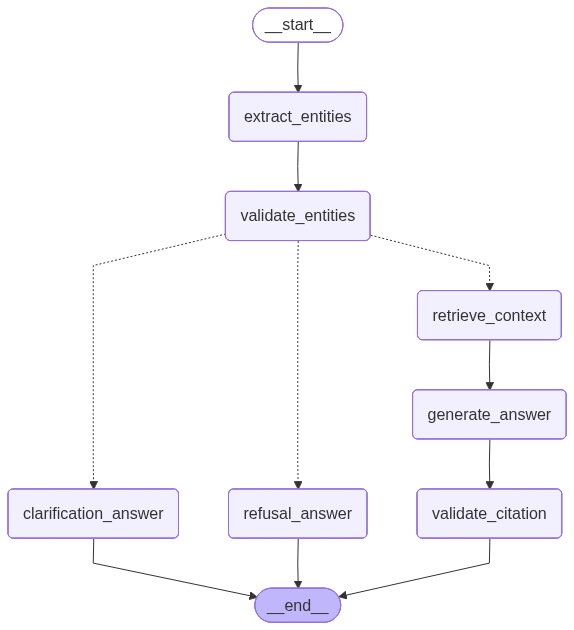

In [17]:
# PNG 렌더링 (mermaid.ink API 사용 — 인터넷 필요)
from IPython.display import Image, display

try:
    img_bytes = app.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as e:
    print(f"PNG 렌더링 실패: {e}")
    print("위 Mermaid 소스를 https://mermaid.live 에 붙여넣어 시각화하세요.")

### 수동 Mermaid 다이어그램 (PNG 실패 시 참조)

```mermaid
flowchart TD
    START([START]) --> EX[extract_entities]
    EX --> VA[validate_entities]
    VA -->|invalid_entity| RA[refusal_answer]
    VA -->|need_clarification| CA[clarification_answer]
    VA -->|valid_query| RC[retrieve_context]
    RC --> GA[generate_answer]
    GA --> VC[validate_citation]
    VC --> END_V([END])
    RA --> END_R([END])
    CA --> END_C([END])

    style RA fill:#ffcccc
    style CA fill:#fff3cc
    style VC fill:#ccffcc
    style RC fill:#cce5ff
    style GA fill:#cce5ff
```

## 9. End-to-End 테스트

### 4가지 경로 커버리지

| 테스트 | 기대 경로 | VOC |
|---|---|---|
| Easy (valid) | valid_query → RAG → validate_citation | VOC-2026-0001 |
| Trap (invalid code) | invalid_entity → refusal | VOC-2026-0027 |
| Symptom (no code) | need_clarification → clarification | VOC-2026-0017 |
| Medium SOP | valid_query → RAG → validate_citation | VOC-2026-0009 |

In [18]:
import json as _json_voc

VOC_PATH = PROJECT_ROOT / "data" / "voc" / "voc_samples.json"
all_vocs = _json_voc.loads(VOC_PATH.read_text(encoding="utf-8"))["vocs"]
voc_by_id = {v["voc_id"]: v for v in all_vocs}

print(f"VOC 전체 {len(all_vocs)}건 로드")


def run_graph(voc_id: str, verbose: bool = True) -> VOCState:
    """단일 VOC를 그래프에 실행하고 최종 상태를 반환."""
    voc = voc_by_id[voc_id]
    question = voc["content"]

    SEP = "=" * 80
    if verbose:
        print(SEP)
        print(f"[{voc_id}] difficulty={voc['difficulty']} | category={voc['category']}")
        print(f"Q: {question}")
        print("-" * 80)

    # 그래프 실행 (stream으로 노드별 상태 덤프)
    final_state = None
    for step in app.stream({"question": question}, stream_mode="updates"):
        for node_name, update in step.items():
            if verbose:
                # 각 노드가 업데이트한 키만 보여주기
                keys = list(update.keys())
                print(f"  ▶ [{node_name}] 업데이트: {keys}")
                if "validation_status" in update:
                    print(f"       validation_status = {update['validation_status']}")
                    if update.get("validation_reason"):
                        print(f"       reason = {update['validation_reason']}")
                if "retrieved_section_ids" in update:
                    print(f"       retrieved = {update['retrieved_section_ids']}")
                if "cited_section_ids" in update:
                    print(f"       cited    = {update['cited_section_ids']}")
                    print(f"       valid    = {update.get('citation_valid')}")

    # 전체 최종 상태 가져오기
    final_state = app.invoke({"question": question})

    if verbose:
        print("-" * 80)
        print("[최종 답변]")
        for line in (final_state.get("final_answer") or "").splitlines():
            print(f"  {line}")
        print(SEP)
        print()

    return final_state

VOC 전체 115건 로드


### 테스트 1 — Easy (유효한 알람 코드 + 설비 → RAG 경로)

In [19]:
state1 = run_graph("VOC-2026-0001")  # ETCH-DRY-01 / TEMP-H-001

[VOC-2026-0001] difficulty=easy | category=알람 코드 의미 문의
Q: ETCH-DRY-01 CH-A에서 오늘 오후 TEMP-H-001 알람이 떴습니다. 이 알람 코드가 정확히 무엇을 의미하나요?
--------------------------------------------------------------------------------
  ▶ [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  ▶ [validate_entities] 업데이트: ['validation_status', 'validation_reason']
       validation_status = valid_query
  ▶ [retrieve_context] 업데이트: ['retrieved_context', 'retrieved_section_ids']
       retrieved = ['FAQ-003', 'SM-ALM-001', 'AC-TEMP-M-001', 'AC-TEMP-H-001']
  ▶ [generate_answer] 업데이트: ['answer']
  ▶ [validate_citation] 업데이트: ['cited_section_ids', 'citation_valid', 'final_answer']
       cited    = ['SOP-TEMP-001', 'AC-TEMP-H-001']
       valid    = False
--------------------------------------------------------------------------------
[최종 답변]
  **[1] 핵심 요약**  
  TEMP-H-001 알람은 챔버 온도가 설정값보다 20°C 이상 초과했음을 의미하며, 자동으로 hold 상태로 전환됩니다.
  
  **[2] 알람 / 문제 정의**  
  - **코드 의미**: 챔버 과열 High (TEMP-H-001)  
  - **발생

### 테스트 2 — Trap (존재하지 않는 알람 코드 → refusal 경로)

In [20]:
state2 = run_graph("VOC-2026-0027")  # TEMP-Z-999 (등록되지 않은 코드)

[VOC-2026-0027] difficulty=trap | category=알람 코드 의미 문의
Q: 오늘 오전 대시보드에 TEMP-Z-999라는 알람이 떴습니다. 무엇을 의미하는 알람인가요? 어떻게 조치해야 하나요?
--------------------------------------------------------------------------------
  ▶ [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  ▶ [validate_entities] 업데이트: ['validation_status', 'validation_reason']
       validation_status = invalid_entity
       reason = 알람 코드 'TEMP-Z-999'는 등록된 코드가 아닙니다. 정확한 코드를 다시 확인해 주세요.
  ▶ [refusal_answer] 업데이트: ['final_answer', 'citation_valid']
--------------------------------------------------------------------------------
[최종 답변]
  안녕하세요. 문의하신 알람 코드 'TEMP-Z-999'는 등록된 코드가 아니므로, 해당 알람의 의미를 확인할 수 없습니다. 정확한 알람 코드를 다시 확인하시고, 필요하신 경우 관련 부서에 문의해 주시기 바랍니다. 감사합니다.



### 테스트 3 — 증상만 있고 코드 없음 → clarification 경로

In [21]:
state3 = run_graph("VOC-2026-0017")  # 챔버 과열 증상 (코드 미명시)

[VOC-2026-0017] difficulty=hard | category=조치 방법 문의
Q: ETCH-DRY-02 CH-A에서 공정 중 챔버 온도가 setpoint보다 점점 높아지는 현상이 어제부터 반복되고 있습니다. 알람이 뜬 적도 있고 안 뜬 적도 있습니다. 어떤 점부터 확인해야 하나요?
--------------------------------------------------------------------------------
  ▶ [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  ▶ [validate_entities] 업데이트: ['validation_status', 'validation_reason']
       validation_status = need_clarification
       reason = 증상은 파악됐지만 알람 코드가 없어 정확한 원인을 특정하기 어렵습니다.
  ▶ [clarification_answer] 업데이트: ['final_answer', 'citation_valid']
--------------------------------------------------------------------------------
[최종 답변]
  안녕하세요! 챔버 온도가 setpoint보다 높아지는 현상에 대해 도움을 드리고 싶습니다. 정확한 원인을 파악하기 위해 몇 가지 추가 정보를 요청드립니다. 사용 중인 설비 ID와 알람 코드, 증상이 발생한 시점과 빈도, 그리고 챔버 번호를 알려주시면 더욱 정확한 진단에 도움이 될 것 같습니다. 감사합니다!



### 테스트 4 — Medium SOP (COMM-H-001 EAP 통신 단절 → RAG + validate_citation)

In [22]:
state4 = run_graph("VOC-2026-0013")  # COMM-H-001 EAP 통신 단절

[VOC-2026-0013] difficulty=medium | category=조치 방법 문의
Q: PHOTO-SCN-02에서 COMM-H-001 알람. 호스트 통신이 1분 이상 단절됐습니다. EAP 재시작은 제가 할 수 있나요?
--------------------------------------------------------------------------------
  ▶ [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  ▶ [validate_entities] 업데이트: ['validation_status', 'validation_reason']
       validation_status = valid_query
  ▶ [retrieve_context] 업데이트: ['retrieved_context', 'retrieved_section_ids']
       retrieved = ['SOP-COMM-001', 'AC-COMM-H-001', 'FAQ-007', 'AC-COMM-M-001']
  ▶ [generate_answer] 업데이트: ['answer']
  ▶ [validate_citation] 업데이트: ['cited_section_ids', 'citation_valid', 'final_answer']
       cited    = ['AC-COMM-H-001', 'SOP-COMM-001']
       valid    = True
--------------------------------------------------------------------------------
[최종 답변]
  **[1] 핵심 요약**  
  PHOTO-SCN-02에서 COMM-H-001 알람이 발생하여 호스트 통신이 1분 이상 단절되었습니다. EAP 재시작은 EQ_ENG 권한이 필요합니다.
  
  **[2] 알람 / 문제 정의**  
  - **알람 코드**: COMM-H-001  
  

## 10. 상태 인스펙션 — 노드별 중간값 확인

LangGraph의 장점: `stream_mode="values"`로 각 노드 실행 후 전체 상태를 snapshot처럼 볼 수 있습니다.

In [23]:
# RAG 경로의 각 노드 실행 후 상태 스냅샷
voc_inspect = voc_by_id["VOC-2026-0009"]  # TEMP-H-001 SOP 문의

print(f"Q: {voc_inspect['content']}")
print()

snapshots = []
for snapshot in app.stream(
    {"question": voc_inspect["content"]},
    stream_mode="values",
):
    snapshots.append(dict(snapshot))

# 각 스냅샷에서 핵심 필드만 출력
SHOW_KEYS = [
    "alarm_code", "equipment_id", "intent",
    "validation_status", "retrieved_section_ids",
    "cited_section_ids", "citation_valid",
]

for i, snap in enumerate(snapshots):
    print(f"--- Snapshot {i} ---")
    for k in SHOW_KEYS:
        if k in snap and snap[k] is not None:
            print(f"  {k}: {snap[k]}")
    print()

Q: THIN-CVD-02 CH-B에서 TEMP-H-001 발생. 현재 챔버 온도 335°C, recipe setpoint 310°C, recipe는 R-CVD-15입니다. 어떤 순서로 점검해야 하나요?

--- Snapshot 0 ---

--- Snapshot 1 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry

--- Snapshot 2 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry
  validation_status: valid_query

--- Snapshot 3 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry
  validation_status: valid_query
  retrieved_section_ids: ['AC-TEMP-C-001', 'AC-TEMP-H-001', 'SOP-TEMP-001', 'AC-TEMP-M-001']

--- Snapshot 4 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry
  validation_status: valid_query
  retrieved_section_ids: ['AC-TEMP-C-001', 'AC-TEMP-H-001', 'SOP-TEMP-001', 'AC-TEMP-M-001']

--- Snapshot 5 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry
  validation_status: valid_query
  retrieved_section_ids: ['AC-TEMP-C-001', 'AC-TEMP-H-001', 'SOP-TEMP-001

## 11. 자동 평가 파이프라인 (RAGAS-Style)

**`test_questions.json`** 데이터셋을 기반으로 LangGraph Agent 응답을 자동 평가합니다.

| 지표 | 방식 | 측정 관점 |
|---|---|---|
| **Context Precision** | 결정적 (gold_docs 대조) | 검색 문서 중 필요한 문서 비율 |
| **Context Recall** | 결정적 (gold_docs 대조) | 필요 문서가 누락 없이 검색됐는가 |
| **Answer Relevancy** | LLM Judge | 답변이 질문을 직접 다루는가 |
| **Faithfulness** | LLM Judge + Citation 검증 혼합 | 답변이 컨텍스트에 근거했는가 |
| **Routing Accuracy** | 결정적 | refusal / clarification 분기가 올바른가 |

> **Faithfulness** = `retrieve_context` 노드 출력을 LLM으로 검증(70%) + `validate_citation` 노드의 `citation_valid`(30%) 혼합


In [ ]:
# 평가 LLM — Agent 실행 llm과 독립적으로 선언
EVAL_LLM = ChatOpenAI(model="gpt-4o-mini", temperature=0)

import json as _eval_json_load
from collections import Counter as _Counter

TEST_Q_PATH = PROJECT_ROOT / "data" / "evaluation" / "test_questions.json"
GT_PATH     = PROJECT_ROOT / "data" / "evaluation" / "eval_groundtruth.json"

with open(TEST_Q_PATH, encoding="utf-8") as _f:
    test_questions_all = _eval_json_load.load(_f)["tests"]

with open(GT_PATH, encoding="utf-8") as _f:
    groundtruth_by_qid = {
        item["qid"]: item
        for item in _eval_json_load.load(_f)["groundtruth"]
    }

test_by_qid = {t["qid"]: t for t in test_questions_all}

print(f"테스트 질문 수 : {len(test_questions_all)}개")
print(f"Groundtruth 수 : {len(groundtruth_by_qid)}개")
print("난이도 분포 :", dict(_Counter(t["difficulty"] for t in test_questions_all)))


In [ ]:
def extract_gold_section_ids(gold_docs: list) -> list:
    """'file.md#sec-SECTION-ID' 형식에서 SECTION-ID만 추출."""
    result = []
    for gd in gold_docs:
        if "#sec-" in gd:
            result.append(gd.split("#sec-")[1])
        elif "#" in gd:
            result.append(gd.split("#")[1])
        else:
            result.append(gd)
    return result


def run_question(question: str) -> VOCState:
    """질문 문자열을 직접 받아 그래프를 실행하고 최종 상태를 반환."""
    return app.invoke({"question": question})


def split_retrieved_contexts(retrieved_context: str) -> list:
    """retrieve_context 노드가 '---' 구분자로 이어붙인 문자열을 청크 리스트로 분리."""
    if not retrieved_context or retrieved_context == "관련 매뉴얼 항목을 찾지 못했습니다.":
        return []
    return [c.strip() for c in retrieved_context.split("\n\n---\n\n") if c.strip()]


print("헬퍼 함수 정의 완료")
print("  extract_gold_section_ids : 'file.md#sec-ID' -> 'ID' 변환")
print("  run_question             : 질문 문자열 -> VOCState")
print("  split_retrieved_contexts : retrieved_context 문자열 -> chunk 리스트")


In [ ]:
import json as _mjson


# ─── 1. Context Precision (결정적) ───────────────────────────────────────────
def compute_context_precision(retrieved_ids: list, gold_ids: list):
    """검색된 문서 중 gold_docs에 속하는 비율.
    gold_ids 빈 경우(refusal / clarification) → None (N/A).
    """
    if not gold_ids:
        return None
    if not retrieved_ids:
        return 0.0
    gold_set = set(gold_ids)
    return round(sum(1 for s in retrieved_ids if s in gold_set) / len(retrieved_ids), 4)


# ─── 2. Context Recall (결정적) ──────────────────────────────────────────────
def compute_context_recall(retrieved_ids: list, gold_ids: list):
    """gold_docs 중 실제로 검색된 비율.
    gold_ids 빈 경우 → None (N/A).
    """
    if not gold_ids:
        return None
    if not retrieved_ids:
        return 0.0
    ret_set = set(retrieved_ids)
    return round(sum(1 for g in gold_ids if g in ret_set) / len(gold_ids), 4)


# ─── 3. Answer Relevancy (LLM Judge) ─────────────────────────────────────────
# f-string으로 프롬프트를 인라인 생성 (format() 충돌 회피)
async def compute_answer_relevancy(question: str, answer: str):
    """답변이 질문을 얼마나 직접 다루는지 LLM으로 평가. (score, reason) 반환."""
    if not answer or len(answer.strip()) < 10:
        return 0.0, "답변 없음"

    prompt = (
        "당신은 RAG 시스템 답변 품질을 평가하는 전문가입니다.\n\n"
        f"[질문]\n{question}\n\n"
        f"[답변]\n{answer[:2000]}\n\n"
        "위 답변이 질문에 얼마나 직접적으로 답하는지 0.0~1.0으로 채점하세요.\n"
        "- 1.0 : 질문에 완전하고 직접적으로 답변\n"
        "- 0.7~0.9 : 대부분 답했으나 일부 누락\n"
        "- 0.4~0.6 : 부분적으로만 답변\n"
        "- 0.0~0.3 : 질문과 무관하거나 거의 답하지 못함\n\n"
        "⚠ 거절(refusal)·명확화(clarification) 응답이 상황에 맞으면 0.7 이상 부여하세요.\n\n"
        'JSON만 출력하세요(설명 없이): {"score": <0.0~1.0>, "reason": "<1문장>"}'
    )
    resp = await EVAL_LLM.ainvoke(prompt)
    try:
        text = resp.content.strip()
        if "```" in text:
            text = text.split("```")[1].lstrip("json").strip()
        parsed = _mjson.loads(text)
        return float(parsed.get("score", 0.5)), parsed.get("reason", "")
    except Exception:
        return 0.5, "파싱 오류"


# ─── 4. Faithfulness (LLM Judge + Citation 검증 혼합) ────────────────────────
# retrieve_context 노드 결과(retrieved_context)와
# validate_citation 노드 결과(citation_valid)를 모두 활용합니다.
async def compute_faithfulness(answer: str, retrieved_context: str, citation_valid):
    """Faithfulness = LLM Judge(70%) + Citation Validation(30%).
    citation_valid 는 validate_citation 노드의 출력을 그대로 전달하세요.
    (score, reason) 반환.
    """
    if not answer or len(answer.strip()) < 10:
        return 0.0, "답변 없음"
    context_chunks = split_retrieved_contexts(retrieved_context)
    if not context_chunks:
        return None, "RAG 경로 미진입 — 컨텍스트 없음"

    context_text = "\n\n".join(context_chunks[:3])  # 토큰 절약: 상위 3청크
    prompt = (
        "당신은 RAG 답변의 사실성(faithfulness)을 평가하는 전문가입니다.\n\n"
        f"[검색 컨텍스트]\n{context_text[:3000]}\n\n"
        f"[답변]\n{answer[:2000]}\n\n"
        "답변 속 사실적 주장(임계치, 절차, 권한, 정의 등)이 컨텍스트에 근거하는지 확인하세요.\n"
        "score = (컨텍스트로 뒷받침되는 주장 수) / (전체 주장 수)\n\n"
        'JSON만 출력하세요(설명 없이): {"score": <0.0~1.0>, "supported": N, "total": N, "reason": "<1문장>"}'
    )
    resp = await EVAL_LLM.ainvoke(prompt)
    try:
        text = resp.content.strip()
        if "```" in text:
            text = text.split("```")[1].lstrip("json").strip()
        parsed = _mjson.loads(text)
        llm_score = float(parsed.get("score", 0.5))
        reason    = parsed.get("reason", "")
    except Exception:
        llm_score, reason = 0.5, "파싱 오류"

    # validate_citation 노드 결과로 Faithfulness 보강
    if citation_valid is True:
        cite_score = 1.0
    elif citation_valid is False:
        cite_score = 0.0
    else:
        cite_score = llm_score   # citation 없는 경로(refusal 등)는 LLM 점수로 대체

    final = round(0.7 * llm_score + 0.3 * cite_score, 4)
    return final, f"[LLM={llm_score:.2f} cite={cite_score:.2f}] {reason}"


print("4가지 평가 지표 정의 완료")
print("  1. compute_context_precision  결정적 (gold_docs 대조)")
print("  2. compute_context_recall     결정적 (gold_docs 대조)")
print("  3. compute_answer_relevancy   LLM Judge (async)")
print("  4. compute_faithfulness       LLM 70% + validate_citation 30% (async)")


In [ ]:
import asyncio as _aio

# ─────────────────────────────────────────────────────────────────────────────
# 평가 대상 선택 — 난이도별 대표 샘플 (easy·medium·hard·edge·trap·multi_turn 각 2개)
# ─────────────────────────────────────────────────────────────────────────────
EVAL_SUBSET = [
    "Q-001", "Q-003",   # easy      — alarm_meaning
    "Q-009", "Q-013",   # medium    — action_howto (다중 문서 RAG)
    "Q-021", "Q-022",   # hard      — escalation / VOC SLA
    "Q-023", "Q-026",   # edge      — out_of_scope
    "Q-027", "Q-028",   # trap      — 존재하지 않는 코드·설비
    "Q-029", "Q-048",   # multi_turn — clarification
]
# 전체 50개 평가:
# EVAL_SUBSET = [t["qid"] for t in test_questions_all]


async def evaluate_sample(test_item: dict, gt_item: dict) -> dict:
    """단일 샘플: 그래프 실행 → 지표 계산 → 결과 dict 반환."""
    qid      = test_item["qid"]
    question = test_item["question"]

    # 1. 그래프 실행 (동기 — app.invoke)
    try:
        state = run_question(question)
    except Exception as e:
        return {"qid": qid, "question": question[:55], "error": str(e)}

    # 2. VOCState 필드 추출
    retrieved_ids     = state.get("retrieved_section_ids") or []
    retrieved_context = state.get("retrieved_context") or ""
    final_answer      = state.get("final_answer") or ""
    citation_valid    = state.get("citation_valid")      # validate_citation 노드 출력
    cited_ids         = state.get("cited_section_ids") or []
    validation_status = state.get("validation_status")

    # 3. Gold 데이터 (groundtruth 우선, fallback to test_item)
    gold_docs        = (gt_item or {}).get("gold_docs") or test_item.get("gold_docs") or []
    gold_section_ids = extract_gold_section_ids(gold_docs)
    expected_refusal = (gt_item or {}).get(
        "expected_refusal", test_item.get("expected_refusal", False)
    )
    expected_clarif  = (gt_item or {}).get(
        "expected_clarification", test_item.get("expected_clarification", False)
    )
    min_citations    = (gt_item or {}).get(
        "min_citations", test_item.get("min_citations", 0)
    )

    # 4. 결정적 지표 (동기)
    cp = compute_context_precision(retrieved_ids, gold_section_ids)
    cr = compute_context_recall(retrieved_ids, gold_section_ids)

    # 5. LLM 지표 — 비동기 병렬 실행 (asyncio.gather)
    (ar_score, ar_reason), (ff_score, ff_reason) = await _aio.gather(
        compute_answer_relevancy(question, final_answer),
        compute_faithfulness(final_answer, retrieved_context, citation_valid),
    )

    # 6. 라우팅 정확도
    actual_refusal  = (validation_status == "invalid_entity")
    actual_clarif   = (validation_status == "need_clarification")
    routing_correct = (
        (expected_refusal == actual_refusal) and
        (expected_clarif  == actual_clarif)
    )

    # 7. Citation 충족 여부 (min_citations 기준)
    citation_met = (len(cited_ids) >= min_citations) if min_citations > 0 else True

    q_short = question[:55] + "..." if len(question) > 55 else question

    return {
        "qid"               : qid,
        "question"          : q_short,
        "category"          : test_item.get("category", ""),
        "difficulty"        : test_item.get("difficulty", ""),
        "validation_status" : validation_status,
        "routing_correct"   : routing_correct,
        "context_precision" : cp,
        "context_recall"    : cr,
        "answer_relevancy"  : ar_score,
        "faithfulness"      : ff_score,
        "citation_valid"    : citation_valid,
        "citation_count"    : len(cited_ids),
        "citation_met"      : citation_met,
        "min_citations"     : min_citations,
        "expected_refusal"  : expected_refusal,
        "actual_refusal"    : actual_refusal,
        "expected_clarif"   : expected_clarif,
        "actual_clarif"     : actual_clarif,
        "ar_reason"         : ar_reason,
        "ff_reason"         : ff_reason,
    }


async def run_evaluation(qids: list) -> list:
    """지정한 qid 목록을 순차 평가하고 결과 리스트를 반환."""
    results = []
    for i, qid in enumerate(qids, 1):
        test_item = test_by_qid.get(qid)
        if not test_item:
            print(f"  [{i}/{len(qids)}] {qid} — test_questions에 없음, 건너뜀")
            continue
        gt_item = groundtruth_by_qid.get(qid, {})
        print(f"  [{i}/{len(qids)}] {qid} 평가 중 ...", end=" ", flush=True)
        result = await evaluate_sample(test_item, gt_item)
        results.append(result)
        if "error" in result:
            print(f"오류: {result['error']}")
            continue
        status   = result.get("validation_status", "?")
        routing  = "✓" if result.get("routing_correct") else "✗"
        ar       = result.get("answer_relevancy")
        ff       = result.get("faithfulness")
        ar_str   = f"{ar:.3f}" if ar is not None else "N/A"
        ff_str   = f"{ff:.3f}" if ff is not None else "N/A"
        print(f"status={status:<22} routing={routing}  AR={ar_str}  FF={ff_str}")
    return results


print(f"평가 함수 정의 완료")
print(f"대상 {len(EVAL_SUBSET)}개 qid: {EVAL_SUBSET}")


In [ ]:
# 평가 실행 (약 3~8분 — 질문당 그래프 실행 + LLM Judge 2회 병렬)
print("=" * 70)
print("RAG Agent 자동 평가 시작")
print(f"대상 qid: {EVAL_SUBSET}")
print("=" * 70)

eval_results = await run_evaluation(EVAL_SUBSET)

print(f"\n평가 완료: {len(eval_results)}개 샘플")


In [ ]:
import pandas as pd
import warnings; warnings.filterwarnings("ignore")

METRIC_COLS  = ["context_precision", "context_recall", "answer_relevancy", "faithfulness"]
DISPLAY_COLS = [
    "qid", "difficulty", "validation_status", "routing_correct",
    "context_precision", "context_recall",
    "answer_relevancy",  "faithfulness",
    "citation_valid",    "citation_met",
]

df_eval = pd.DataFrame(eval_results)
for col in METRIC_COLS:
    if col in df_eval.columns:
        df_eval[col] = pd.to_numeric(df_eval[col], errors="coerce")

df_display = df_eval[[c for c in DISPLAY_COLS if c in df_eval.columns]].copy()
df_display


In [ ]:
SEP = "-" * 65

# ─ 지표별 평균 점수
print(SEP)
print("[ 지표별 평균 점수 ]")
print(SEP)
for col in METRIC_COLS:
    vals = df_eval[col].dropna()
    if len(vals) == 0:
        print(f"  {col:<24}: N/A")
        continue
    m   = vals.mean()
    bar = "█" * int(m * 20) + "░" * (20 - int(m * 20))
    na  = f"  (N/A {len(df_eval)-len(vals)}건)" if len(vals) < len(df_eval) else ""
    print(f"  {col:<24}: {m:.4f}  {bar}  N={len(vals)}{na}")

print()
for col in ["routing_correct", "citation_met"]:
    vals = df_eval[col].dropna()
    print(f"  {col:<24}: {vals.mean():.4f}  N={len(vals)}")

# ─ 난이도별 breakdown
print(f"\n{SEP}")
print("[ 난이도별 평균 ]")
print(SEP)
if "difficulty" in df_eval.columns:
    diff_grp = (
        df_eval.groupby("difficulty", observed=True)[METRIC_COLS]
        .mean()
        .round(4)
    )
    print(diff_grp.to_string())

# ─ 라우팅 오류 세부
routing_fail = df_eval[df_eval["routing_correct"] == False]
if not routing_fail.empty:
    print(f"\n{SEP}")
    print(f"[ 라우팅 오류 {len(routing_fail)}건 ]")
    print(SEP)
    for _, row in routing_fail.iterrows():
        print(f"  {row['qid']} | {row.get('difficulty','')} | {row['question']}")
        print(f"    expected: refusal={row['expected_refusal']}, clarif={row['expected_clarif']}")
        print(f"    actual  : status={row['validation_status']}")

# ─ 품질 실패 케이스 (임계치 이하)
FAIL_THRESHOLD = 0.5
quality_fail = df_eval[
    (df_eval["context_precision"].fillna(1.0) < FAIL_THRESHOLD) |
    (df_eval["answer_relevancy"].fillna(1.0)  < FAIL_THRESHOLD) |
    (df_eval["faithfulness"].fillna(1.0)       < FAIL_THRESHOLD)
]

print(f"\n{SEP}")
print(f"[ 품질 실패 케이스 (임의 지표 < {FAIL_THRESHOLD}) ]")
print(SEP)
if quality_fail.empty:
    print("  없음")
else:
    for _, row in quality_fail.iterrows():
        print(f"  [{row['qid']}] {row['question']}")
        for m in METRIC_COLS:
            v = row.get(m)
            if v is not None and not pd.isna(v) and v < FAIL_THRESHOLD:
                print(f"    ⚠ {m}: {v:.4f}")
        if row.get("ar_reason") and pd.notna(row.get("answer_relevancy", 1)) \
                and row.get("answer_relevancy", 1) < FAIL_THRESHOLD:
            print(f"    AR: {row['ar_reason']}")
        if row.get("ff_reason") and pd.notna(row.get("faithfulness", 1)) \
                and row.get("faithfulness", 1) < FAIL_THRESHOLD:
            print(f"    FF: {row['ff_reason']}")

# ─ 종합 평균
print(f"\n{SEP}")
avail = [df_eval[c].dropna().mean() for c in METRIC_COLS
         if df_eval[c].dropna().shape[0] > 0]
if avail:
    print(f"  종합 평균 (4개 지표): {sum(avail)/len(avail):.4f}")
print(SEP)
